# Zufallszahlen Simulieren

## Arbeitsblatt zur Einarbeitung

Dieses Arbeitsblatt soll durchgearbeitet werden, bevor mit der Vertiefung begonnen wird. Die Lösungen werden zwischen Freitag Abend und Montag Morgen hochgeladen.

Das Ziel ist, ein einfaches Verständnis für den Nutzen von Zufallszahlen in der Simulation von stochastischen Prozessen zu erlangen.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Stochastische Prozesse

Ein [stochastischer Prozess](https://de.wikipedia.org/wiki/Stochastischer_Prozess) ist ein Modell, das die zeitliche Entwicklung eines Systems oder Phänomens beschreibt. Dabei wird berücksichtigt, dass Zufallseinflüsse eine Rolle spielen können. Im Gegensatz zu deterministischen Prozessen, bei denen der zukünftige Zustand eines Systems eindeutig aus dem aktuellen Zustand bestimmt werden kann, können bei stochastischen Prozessen zufällige Ereignisse auftreten, welche die zukünftige Entwicklung unsicher machen.

Stochastische Prozesse sind in vielen wissenschaftlichen Disziplinen von grosser Bedeutung, wie zum Beispiel in der Physik, Chemie, Biologie, Ökonomie, Informatik und Statistik. Sie werden häufig verwendet, um natürliche Phänomene, wirtschaftliche Entwicklungen oder technische Systeme zu modellieren, bei denen Unsicherheit oder zufällige Fluktuationen eine Rolle spielen. Beispiele für stochastische Prozesse:

- [Wienerprozess (Brownsche Bewegung)](https://de.wikipedia.org/wiki/Wienerprozess)
- [Poisson-Prozess](https://de.wikipedia.org/wiki/Poisson-Prozess)
- [Random Walk](https://de.wikipedia.org/wiki/Random_Walk)

[Markow-Ketten](https://de.wikipedia.org/wiki/Markow-Kette) sind ein spezieller Typ von stochastischen Prozessen, bei denen die Zustandsänderung des Systems in einem Zeitschritt $\Delta t$ nur vom aktuellen Zustand (zur Zeit $t$) abhängt und nicht von den vorherigen Zuständen (Historie). Sie haben also ein "kurzes Gedächtnis".

Man kann sich das als ein Spiel vorstellen, bei dem man eine Entscheidung nur abhängig von der aktuellen Spielsituation und nicht von vorherigen Entscheidungen trifft. Die Wahrscheinlichkeiten, von einem Zustand des Systems in einen anderen Zustand überzugehen, sind konstant und werden in einer sogenannten Übergangsmatrix dargestellt.

Schau dir dazu eines der beiden Videos an:

- ["Markoff Kette, Markov Kette, Übergangsprozess, stochastischer Prozess" - Daniel Jung](https://youtu.be/NKoPwE2LQhc)
- ["Markov Chains Clearly Explained! Part - 1" - Normalized Nerd](https://youtu.be/i3AkTO9HLXo)

Weitere Videos (optional):

- ["Stochastische Prozesse, Übergangsgraph, Übergangsdiagramm, Zustände" - Fit im Mathe-Abi"](https://www.youtube.com/watch?v=DsnMqNZRxgM)
- ["Markoff Kette, Markov Kette, Übergangsprozess, stochastischer Prozess" - Mathe by Daniel Jung](https://www.youtube.com/watch?v=NKoPwE2LQhc)
- ["Introducing Markov Chains" - Harvard Online](https://www.youtube.com/watch?v=JHwyHIz6a8A)
- ["Intro to Markov Chains & Transition Diagrams" - Dr. Trefor Bazett](https://www.youtube.com/watch?v=rHdX3ANxofs)

## Diffusion

Als erstes Beispiel betrachten wir ein einfaches Modell der Diffusion.

Unter Diffusion versteht man in der Physik einen Vorgang, bei dem ein Stoff aufgrund molekularer Bewegung in einen anderen eindringt oder ihn ganz durchdringt.

Modell: Ein mit Teilchen gefüllter Kasten ist durch eine durchlässige Wand in zwei Hälften A und B geteilt. Die Verteilung der Teilchen auf die beiden Hälften ändert sich jeweils nach Ablauf einer festen Zeiteinheit $\Delta t$: 10 % der sich in A befindlichen Teilchen gelangen nach B (die restlichen 90 % bleiben in A) und 20 % der sich in B befindlichen Teilchen gelangen nach A (die restlichen 80 % bleiben in B).

> ![Prozessdiagramm Diffusion](diffusion.png)
>
> Meyer, J. (o. J.). *Modellieren und Rechnen mit Matrizen* [Skript]. Mathe-Sport-Lehrer. Abgerufen 27. Januar 2026, von https://www.maspole.de/index.php/mathematikunterricht/jahrgang-13-g9-q2-phase/modellieren-mit-matrizen/download/88-modellieren-und-rechnen-mit-matrizensse/1036-13-modellieren-und-rechnen-mit-matrizen-skript

Das Modell ist ein Markow-Prozess, da der Übergang von einem Zustand in den nächsten nur vom aktuellen Zustand (Anzahl Teilchen in A oder B) abhängt und nicht von den vorherigen Zuständen.


## Arbeitsauftrag

### Aufgabe 1: Vorbereitungen

#### a) Repetition `rng.choice`

Bevor wir direkt mit der Implementierung der Diffusion beginnen, kommt hier eine kleine Repetition der Funktion [`rng.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.choice.html). Hierfür wird das folgende Beispiel verwendet:

Wir werfen eine unfaire Münze, welche zu 60 % Kopf und zu 40 % Zahl zeigt. Schreibe hierfür eine Funktion `toss_coin(n, rng)`, welche das Ergebnis von `n` Münzwürfen zurückgibt. Als Argument nimmt sie einen NumPy Random Generator `rng`. Benutze hierfür die Funktion [`rng.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.choice.html).

Teste deine Funktion, indem du 5 Würfe simulierst. Mit dem Default Random Generator und dem Seed 42 sollte das Ergebnis `["Zahl", "Kopf", "Zahl", "Zahl", "Kopf"]` sein.

In [2]:
rng = np.random.default_rng(42)

In [3]:
# Die möglichen Ergebnisse eines Münzwurfs
outcomes = ["Kopf", "Zahl"]

# Die Wahrscheinlichkeiten für die beiden Ergebnisse
probabilities = [0.6, 0.4]


def toss_coin(n, rng):
    return rng.choice(outcomes, p=probabilities, size=n)


toss_coin(5, rng)

array(['Zahl', 'Kopf', 'Zahl', 'Zahl', 'Kopf'], dtype='<U4')

#### b) Repetition Häufigkeiten zählen und darstellen mit Pandas

Führe 1000 Münzwürfe mit der Funktion `toss_coin` aus Aufgabe 1 a) durch und speichere das Ergebnis in einer Variablen `coins`.

Bestimme die absoluten Häufigkeit der Ergebnisse mit der Funktion [`pd.Series.value_counts`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.value_counts.html).

Dann bestimme die relativen Häufigkeiten mit der Funktion [`pd.Series.value_counts`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.value_counts.html) und dem Argument `normalize=True` und stelle diese mit der Funktion [`pd.Series.plot`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.plot.html) dar.

In [4]:
n = 1000
coins = toss_coin(n, rng)

pd.Series(coins).value_counts()

Kopf    605
Zahl    395
Name: count, dtype: int64

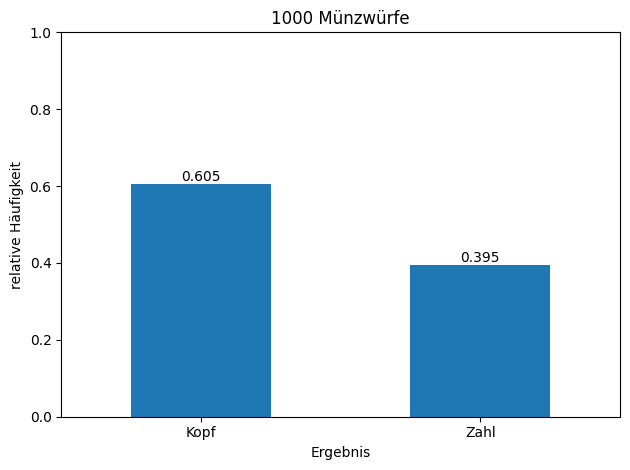

In [5]:
ax = (
    pd.Series(coins)
    .value_counts(normalize=True)
    .plot.bar(
        title=f"{n} Münzwürfe",
        xlabel="Ergebnis",
        ylabel="relative Häufigkeit",
        rot=0,
    )
)
ax.bar_label(ax.containers[0])
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### Aufgabe 2: Implementierung der Diffusion

Wir implementieren eine einfache Version des Diffusionsmodells. Hier ist nochmals das Prozessdiagramm:

> ![Prozessdiagramm Diffusion](diffusion.png)
>
> Meyer, J. (o. J.). *Modellieren und Rechnen mit Matrizen* [Skript]. Mathe-Sport-Lehrer. Abgerufen 27. Januar 2026, von https://www.maspole.de/index.php/mathematikunterricht/jahrgang-13-g9-q2-phase/modellieren-mit-matrizen/download/88-modellieren-und-rechnen-mit-matrizensse/1036-13-modellieren-und-rechnen-mit-matrizen-skript


#### a) Implementierung Schritt 1

Programmiere zuerst eine Funktion namens `markov_next(x, rng)`, die den aktuellen Zustand `x` eines Teilchens und einen Random Generator `rng` als Parameter nimmt. Die Funktion soll den nächsten Zustand zurückgeben. Die Übergangswahrscheinlichkeiten sind $p_{AB} = 0.1$ und $p_{BA} = 0.2$. Benutze hierfür die Funktion `rng.choice()`.

Verwende `A = 0` und `B = 1` für die möglichen Zustände, anstatt mit den Strings `"A"` und `"B"` zu arbeiten.

Test die Funktion mit dem Anfangszustand `x = A` und dem Seed 12345678. Das Ergebnis sollte `1` sein (also Zustand B).

In [6]:
A, B = 0, 1
p_AB = 0.1
p_BA = 0.2


def markov_next(x, rng):
    if x == A:
        return rng.choice((A, B), p=(1 - p_AB, p_AB))
    else:
        return rng.choice((A, B), p=(p_BA, 1 - p_BA))


rng = np.random.default_rng(12345678)
markov_next(A, rng)

np.int64(1)

#### b) Implementierung des gesamten Prozesses

Nun schreibst du eine Funktion `markov_process(n, x0, seed=12345678)`, die eine Anzahl Schritte `n`, einen Startwert `x0` und den Seed mit Standardwert 12345678 als Parameter nimmt. Sie soll einen Default Random Generator und die Funktion `markov_next()` benutzen, um ausgehend vom Startwert eine Liste von `n` Schritten in der Markov-Kette zu erzeugen. Die Funktion soll den Verlauf der Zustände inkl. des Anfangszustandes als Array zurückgeben.

In [7]:
def markov_process(n, x0, seed=12345678):
    rng = np.random.default_rng(seed)
    x = x0
    xs = [x]
    for _ in range(n):
        x = markov_next(x, rng)
        xs.append(x)
    return np.array(xs)

#### c) Testen der Funktion

Teste die Funktion `markov_process()` mit der Anzahl Schritte `n=10`, dem Startwert `x0=A`, einem Random Generator mit dem Seed `12345678`.

Das Resultat sollte so aussehen: `[0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1]`.

In [8]:
markov_process(10, A)

array([0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1])

#### d) Verlauf mit Stemplot darstellen


Um sich einen Überblick über die zeitliche Veränderung in der Markov-Kette zu machen, plotten wir nun die Zustände in Abhängigkeit der Zeit (= Schritt). Hierfür verwenden wir die Funktion [`plt.stem`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.stem.html). Wir nehmen den gleichen Seed und Startwert wie in Aufgabe 2c), jedoch erhöhen wir die Anzahl Schritte auf `n = 30`.

Verändere den Seed und beobachte, wie sich der Verlauf der Zustände ändert.

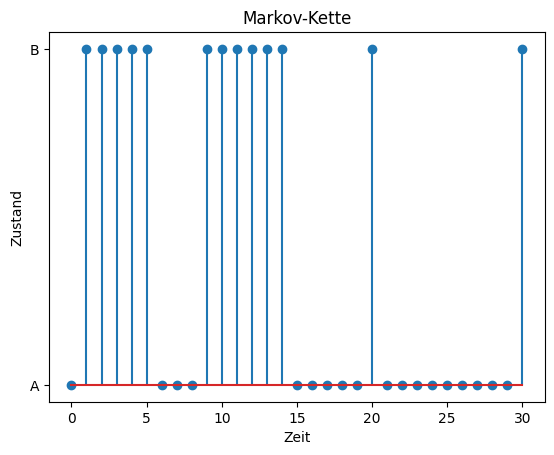

In [9]:
y = markov_process(30, A, 12345678)

plt.stem(y)
plt.xlabel("Zeit")
plt.ylabel("Zustand")
plt.yticks((A, B), ("A", "B"))
plt.title("Markov-Kette")
plt.show()

#### e) Statistik mit Barplot darstellen

Erzeuge nun eine Markov-Kette `chain` mit `n = 1000` Schritten und dem Seed 12345678.

Zähle die absoluten Häufigkeiten mit Pandas und gib das Resultat aus.

Dann erstelle einen Barplot der relativen Häufigkeit mit Pandas.

Was fällt dir auf? Beschreibe die Verteilung der Zustände. Und wie hängt diese von Seed und Anzahl Schritten ab?

In [10]:
n = 1000
chain = markov_process(n, A)
pd.Series(chain).value_counts()

0    610
1    391
Name: count, dtype: int64

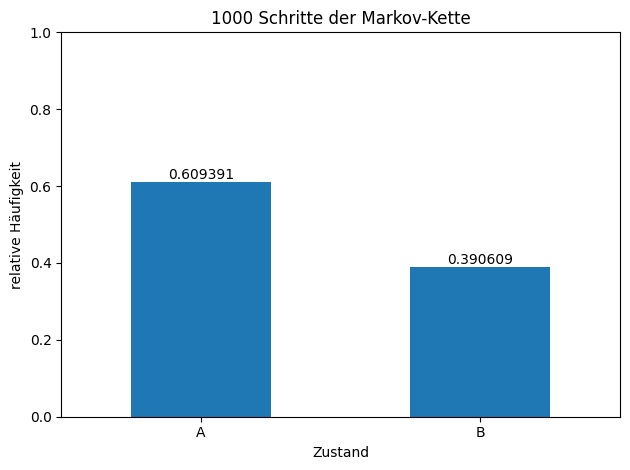

In [11]:
ax = (
    pd.Series(chain)
    .value_counts(normalize=True)
    .rename({A: "A", B: "B"})
    .plot(
        kind="bar",
        title=f"{n} Schritte der Markov-Kette",
        xlabel="Zustand",
        ylabel="relative Häufigkeit",
        rot=0,
    )
)
ax.bar_label(ax.containers[0])
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

Die relative Häufigkeit der Zustände sollte sich bei genügend vielen Schritten einem Gleichgewicht annähern. Dieses Gleichgewicht wird als stationäre Verteilung bezeichnet. Und die stationäre Verteilung hängt nicht vom Startwert und dem Random Seed ab.

Für dieses Beispiel könnte die stationäre Verteilung analytisch berechnet werden. Wir können sie aber auch durch Simulation bestimmen, indem wir die Markov-Kette für eine grosse Anzahl Seeds simulieren und dann die Verteilung der Häufigkeit der Zustände pro Seed bestimmen anschauen. 

In [12]:
def get_relative_frequency_A(chain):
    return pd.Series(chain).value_counts(normalize=True)[A]


n_steps = 1000
n_chains = 1000
chains = [markov_process(n_steps, A, None) for _ in range(n_chains)]
freqs = np.array([get_relative_frequency_A(chain) for chain in chains])

freqs[:10]

array([0.62737263, 0.67232767, 0.70829171, 0.67132867, 0.63636364,
       0.6033966 , 0.63036963, 0.66333666, 0.67132867, 0.68031968])

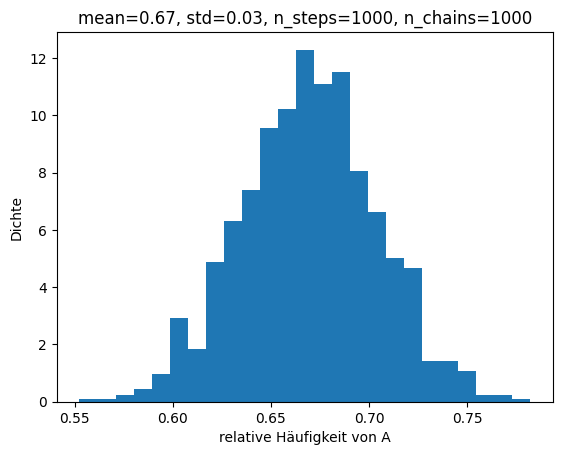

In [13]:
plt.hist(freqs, density=True, bins="fd")
plt.xlabel("relative Häufigkeit von A")
plt.ylabel("Dichte")
plt.title(
    f"mean={np.mean(freqs):.2f}, std={np.std(freqs):.2f}, n_steps={n_steps}, n_chains={n_chains}"
)
plt.show()